In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import ellipk
from scipy.signal import find_peaks, peak_widths
from scipy.constants import mu_0, epsilon_0
from scipy.optimize import root, curve_fit
from functools import partial
from scipy.io import loadmat

In [2]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [3]:
import h5py

In [4]:
def del_sol(delta, a, phi_ext_val):
    
    lhs = delta + a * np.sin(delta)
    
    return lhs - phi_ext_val


# calculates the impedance of the coupling capacitor to the transmission line (not shown in the setup)
def c_cap(c_c, w):
    return np.array([[1,1/(1j*c_c*w)],[0,1]])

# calculates the impedance of the resonator
def tline(Z0, beta, L):
    return np.array([[np.cos(beta*L),1j*Z0*np.sin(beta*L)],[1j*(1/Z0)*np.sin(beta*L),np.cos(beta*L)]])


def Z_L(L_01, L_02, L_T, d, w, R):
    ZL01 = 1j*w*L_01
    ZL02 = 1j*w*L_02
    ZLT = 1j*w*L_T/np.cos(d)
    ZL02R = (1/ZL02 + 1/R)**(-1)
    ZSQUID = (1/ZL01 + 1/(ZLT + ZL02R))**(-1)
    
    return ZSQUID

def Z_tot(ZL, Z0, beta, l, c_c, w):
    x = beta*l
    Z_c = 1/(1j*w*c_c)
    return (Z0*((ZL + 1j*Z0*np.tan(x))/(Z0 + 1j*ZL*np.tan(x)))) + Z_c

def branch(Z):
    return np.array([[1,0], [1/Z, 1]])
    
#calculates the ABCD matrix
def ABCD(M1, M2, M3):
    full_M = M1 @ M2 @ M3 
    
    return full_M
#Calculates the S21 parameter
def S21(A, B, C, D, Z0):
    return 2/(A + B/Z0 + C*Z0 + D)


def current_to_flux(I, M, o):
    return M*I + o


In [56]:
def solve_delta(phi_ext, a):
    phi_ext = np.asarray(phi_ext)
    delta = np.zeros_like(phi_ext, dtype=float)
    order = np.argsort(phi_ext)          # continuity in phi_ext, not array position
    d0 = 0.0
    for idx in order:
        sol = root(del_sol, d0, args=(a, phi_ext[idx]))
        delta[idx] = sol.x[0]
        d0 = sol.x[0]
    return delta

def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, Z0=50):
    """
    X = (I, f): current (A) and frequency (Hz) arrays, same length (elementwise pairs).
    Fit params: L0 (=L01=L02), LT, L_l, C_l, C_c, R_j
    Fixed:      l_f (resonator length), M, O (current -> flux calibration)
    """
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O #np.pi - 0.5 -0.25 - 0.25 - 0.25

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    beta = w * np.sqrt(L_l * C_l)
    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)

    return 2 / (2 + Z0 / Ztot)

def S21_fit_mag_dB(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f):
    S21 = S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f)
    return 20 * np.log10(np.abs(S21))

In [6]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}

def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



def calc_target_frequency(target_length: float, cpw_param_set: dict):
    return 1e6 / (4 * target_length * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



resonator_widths = [7, 10, 7]
#################################3

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)
l = calc_target_length(5.5e9, res_cpw_param_set)
R_L = l/1e6
L_l = res_cpw_param_set['inductance']
C_l = res_cpw_param_set['capacitance']
R_L

np.float64(0.005122618693762872)

In [7]:
mat_data_s21 = loadmat('TC-Main-001-S21-Fit-test1.mat', squeeze_me=True)
mat_data_freq = loadmat('Tc-Main-001-F-fit-test1.mat', squeeze_me=True)
mat_data_current = loadmat('TC-Main-001-I-fit-test1.mat', squeeze_me = True)
mat_data_f0 = loadmat('TC-Main-001-f0-fit-all.mat', squeeze_me = True)
mat_data_I1 = loadmat('TC-Main-001-I1-fit-all.mat', squeeze_me = True)
mat_data_Q_ext = loadmat('TC-Main-001-Q-ext-fit-all.mat', squeeze_me = True)
mat_data_Q_L = loadmat('TC-Main-001-Q-L-fit-all.mat', squeeze_me = True)
mat_data_Q_int = loadmat('TC-Main-001-Q-int-fit-all.mat', squeeze_me = True)


print(mat_data_Q_int.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Qi_all'])


In [8]:
S21_dB = mat_data_s21['S21_fit'] 
Freq = mat_data_freq['F_fit']
I1 = mat_data_current['I_fit']
f0_all = mat_data_f0['f0_all']
I1_all = mat_data_I1['I1_all']
Q_ext_all = mat_data_Q_ext['Qext_all']
Q_L_all = mat_data_Q_L['QL_all']
Q_int_all = mat_data_Q_int['Qi_all']

print(I1.shape, Freq.shape, S21_dB.shape)

(200316,) (200316,) (200316,)


In [19]:
# order: L0, LT, L_l, C_l, C_c, R_j, M, O
#         (M is unsigned-magnitude known, sign unknown -> let it range over ±)

M_mag = 2*np.pi / 2.15e-6   # ~2.96e6 rad/A, from your I-axis period

lower_bounds = [
    0.17e-9,      # L0
    0.40e-9,       # LT
    0.6*L_l,      # L_l  (calculated value, allow ~10% fab tolerance)
    0.6*C_l,      # C_l
    50e-15,       # C_c
    10,            # R_j   
    -1.1*M_mag,   # M - sign unknown, so let it span negative too
    np.pi-1.75,          # O
]

upper_bounds = [
    0.22e-9,      # L0
    0.55e-9,       # LT
    1.1*L_l,      # L_l
    1.1*C_l,      # C_l
    55e-15,       # C_c
    30,         # R_j
    1.1*M_mag,    # M
    2*np.pi,      # O
]



p0 = [
    0.2e-9,       # L0
    0.45e-9,       # LT
    L_l,          # L_l
    C_l,          # C_l
    51e-15,       # C_c
    20,           # R_j    
    M_mag,        # M      - pick positive sign as starting guess, refit with negative if it fails
    np.pi-1.25,        # O      - roughly mid-period as a neutral starting guess
]

fit_func = partial(S21_fit_mag_dB, l_f=R_L)

I1_A = I1 * 1e-6  # convert µA -> A

# --- Recover segment boundaries from the unique-current counts (101, 19, 96) ---
I_unique = np.unique(I1_A)
seg_sizes = [101, 19, 96]
seg_bounds = np.cumsum([0] + seg_sizes)  # [0, 101, 120, 216]
segments = {
    'Segment 1': I_unique[seg_bounds[0]:seg_bounds[1]],
    'Segment 2': I_unique[seg_bounds[1]:seg_bounds[2]],
    'Segment 3': I_unique[seg_bounds[2]:seg_bounds[3]],
}

# --- Weight 1: give the dip itself more say than baseline noise ---
weights = 1.0 / (1.0 + np.abs(S21_dB))

# --- Weight 2: rebalance segments so point-count imbalance doesn't drown out segment 2 ---
seg_id = np.zeros_like(I1_A, dtype=int)
seg_id[np.isin(I1_A, segments['Segment 2'])] = 1
seg_id[np.isin(I1_A, segments['Segment 3'])] = 2
seg_counts = np.array([np.sum(seg_id==0), np.sum(seg_id==1), np.sum(seg_id==2)])
seg_weight = 1.0 / seg_counts[seg_id]
seg_weight /= seg_weight.mean()

total_weight = weights * seg_weight
sigma = 1.0 / total_weight


popt, pcov = curve_fit(
    fit_func, (I1_A, Freq), S21_dB,
    p0=p0, bounds=(lower_bounds, upper_bounds), sigma=sigma
)
L0_fit, LT_fit, Ll_fit, Cl_fit, Cc_fit, Rj_fit, M_fit, O_fit = popt

In [20]:
popt

array([1.97875647e-10, 4.90199839e-10, 5.10327860e-07, 1.43941396e-10,
       5.22793055e-14, 1.81420012e+01, 2.92286415e+06, 1.89145123e+00])

In [21]:
a = 2*L0_fit/LT_fit

f0 = 1/(np.sqrt(Ll_fit*Cl_fit*R_L**2)*4)
a, f0/1e9

(np.float64(0.8073264449727889), np.float64(5.694170733103786))

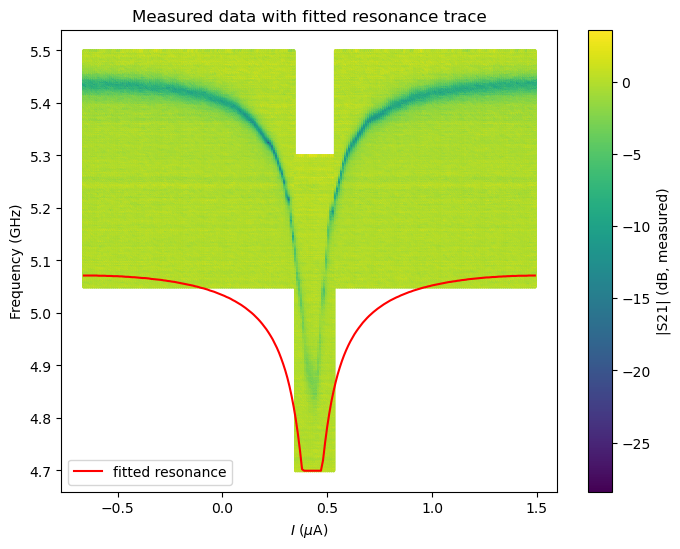

In [18]:
# Dense frequency grid spanning your full measurement range, not tied to segment sampling
f_dense = np.linspace(Freq.min(), Freq.max(), 2000)

I_unique = np.unique(I1_A)
f0_fit_trace = np.zeros_like(I_unique)

for i, I_val in enumerate(I_unique):
    I_dense = np.full_like(f_dense, I_val)
    model_dense = fit_func((I_dense, f_dense), *popt)
    f0_fit_trace[i] = f_dense[np.argmin(model_dense)]

plt.figure(figsize=(8, 6))
sc = plt.scatter(I1_A*1e6, Freq/1e9, c=S21_dB, s=2, cmap='viridis')
plt.colorbar(sc, label='|S21| (dB, measured)')
plt.plot(I_unique*1e6, f0_fit_trace/1e9, 'r-', lw=1.5, label='fitted resonance')
plt.xlabel(r'$I$ ($\mu$A)')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.title('Measured data with fitted resonance trace')
plt.show()

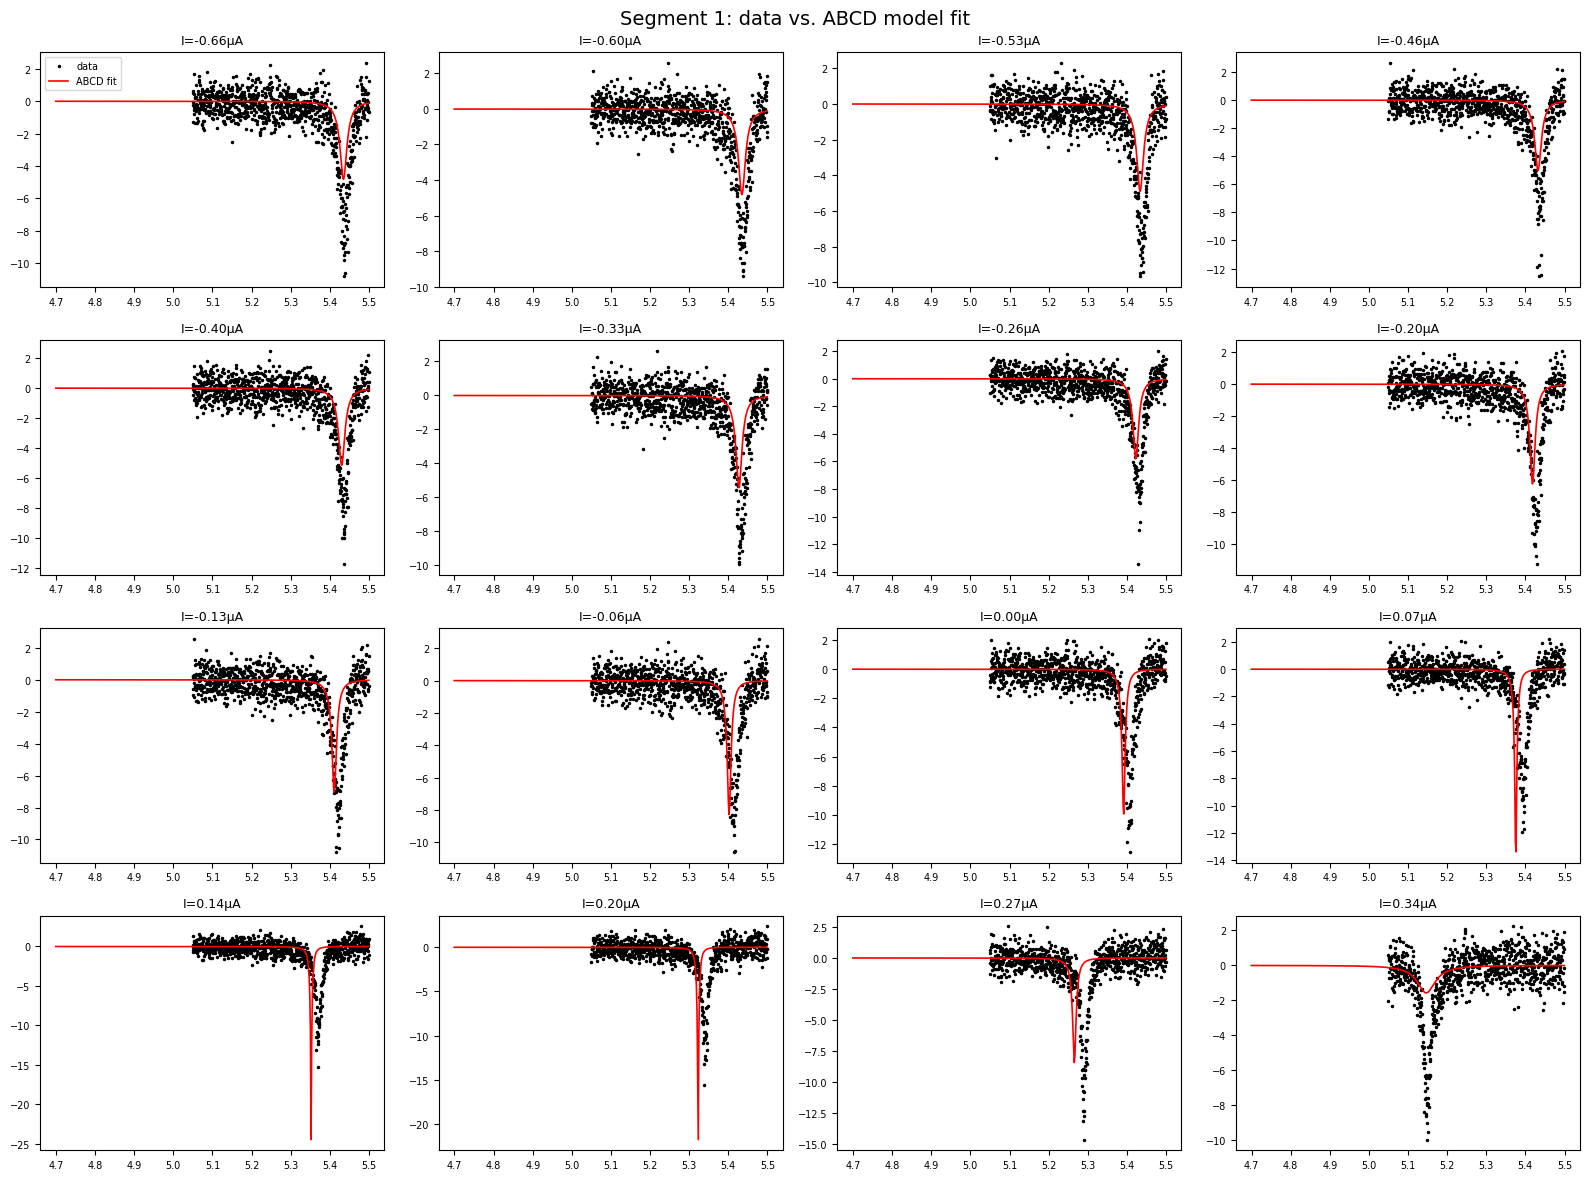

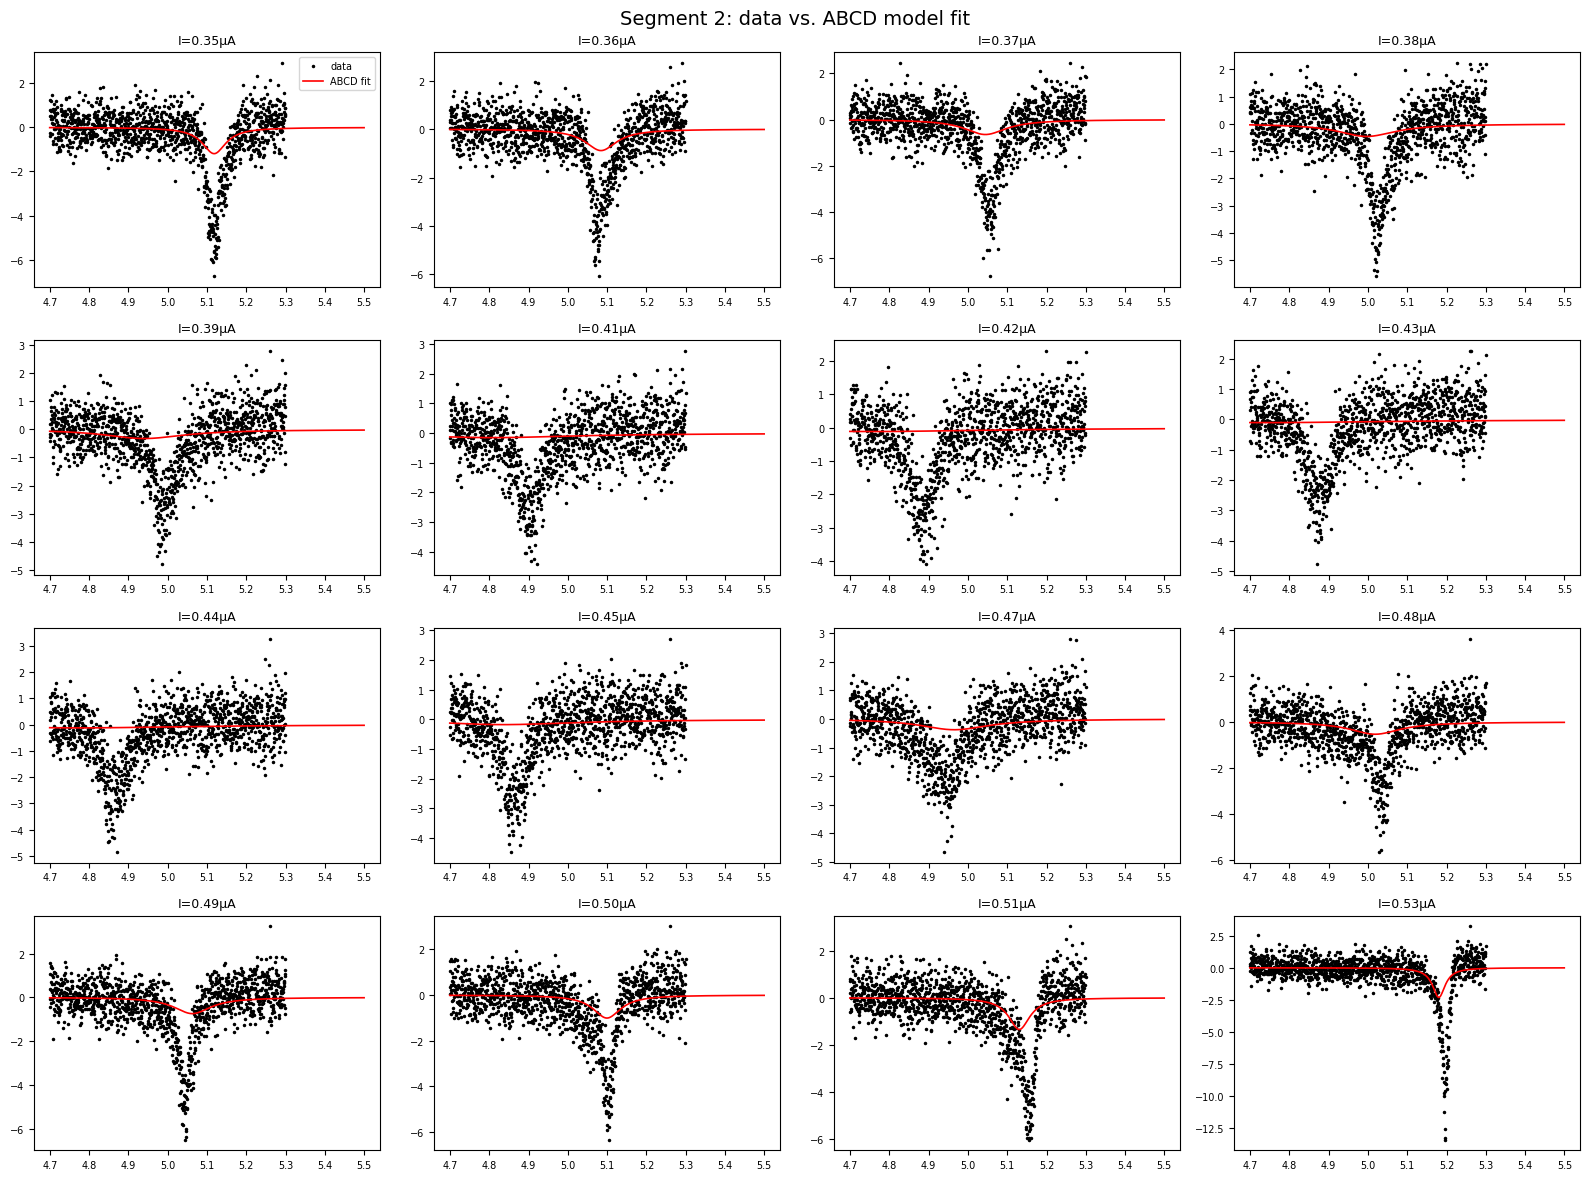

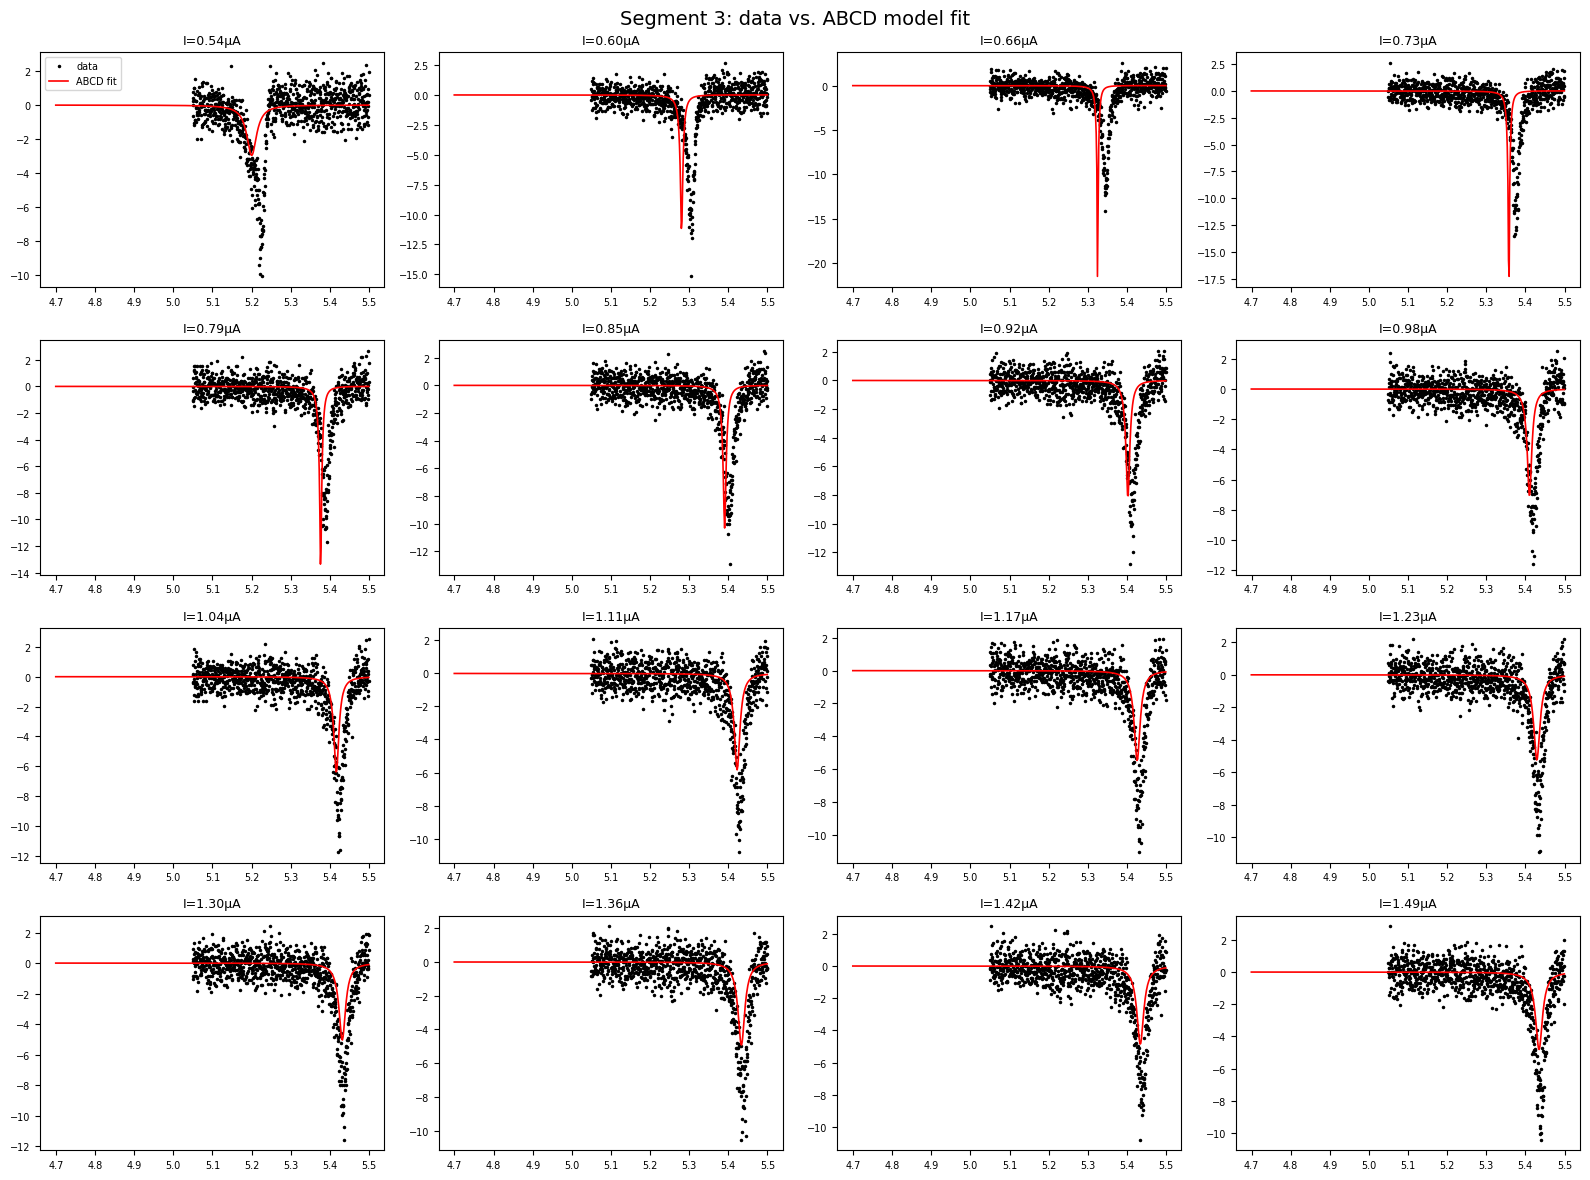

In [ ]:
# --- Recover segment boundaries from the unique-current counts (101, 19, 96) ---
I_unique = np.unique(I1_A)
seg_sizes = [101, 19, 96]
seg_bounds = np.cumsum([0] + seg_sizes)  # [0, 101, 120, 216]
segments = {
    'Segment 1': I_unique[seg_bounds[0]:seg_bounds[1]],
    'Segment 2': I_unique[seg_bounds[1]:seg_bounds[2]],
    'Segment 3': I_unique[seg_bounds[2]:seg_bounds[3]],
}

f_dense = np.linspace(Freq.min(), Freq.max(), 500)

# --- Plot 16 evenly-spaced traces per segment: data vs. ABCD model fit ---
for seg_name, I_seg in segments.items():
    n_show = min(16, len(I_seg))
    sample_idx = np.linspace(0, len(I_seg)-1, n_show).astype(int)
    sample_currents = I_seg[sample_idx]

    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    fig.suptitle(f'{seg_name}: data vs. ABCD model fit', fontsize=14)

    for ax, I_val in zip(axes.flat, sample_currents):
        mask = (I1_A == I_val)
        f_trace = Freq[mask]
        S21_trace = S21_dB[mask]
        order = np.argsort(f_trace)
        f_trace, S21_trace = f_trace[order], S21_trace[order]

        ax.plot(f_trace/1e9, S21_trace, 'k.', ms=3, label='data')

        I_dense = np.full_like(f_dense, I_val)
        model_dense = fit_func((I_dense, f_dense), *popt)
        ax.plot(f_dense/1e9, model_dense, 'r-', lw=1.2, label='ABCD fit')

        ax.set_title(f'I={I_val*1e6:.2f}µA', fontsize=9)
        ax.tick_params(labelsize=7)

    for ax in axes.flat[n_show:]:
        ax.axis('off')

    axes.flat[0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
def empirical_dip_center(f_trace, S21_trace, n_lowest=5):
    """Robust dip-center estimate: frequency-weighted centroid of the n_lowest points."""
    order = np.argsort(S21_trace)
    lowest_idx = order[:n_lowest]
    weights = -S21_trace[lowest_idx]  # deeper points get more weight
    weights -= weights.min() - 1e-6   # keep positive
    return np.average(f_trace[lowest_idx], weights=weights)

I_unique = np.unique(I1_A)
f0_data = np.zeros_like(I_unique)
for i, I_val in enumerate(I_unique):
    mask = (I1_A == I_val)
    f0_data[i] = empirical_dip_center(Freq[mask], S21_dB[mask])

In [ ]:
def model_f0(I_val, L0, LT, L_l, C_l, M, O, C_c_fixed, R_j_fixed, l_f, f_dense):
    I_dense = np.full_like(f_dense, I_val)
    model_vals = S21_fit_mag_dB((I_dense, f_dense), L0, LT, L_l, C_l, C_c_fixed, R_j_fixed, M, O, l_f)
    return f_dense[np.argmin(model_vals)]

def position_residuals(params, I_arr, f0_data_arr, C_c_fixed, R_j_fixed, l_f, f_dense):
    L0, LT, L_l, C_l, M, O = params
    model_f0_arr = np.array([
        model_f0(I_val, L0, LT, L_l, C_l, M, O, C_c_fixed, R_j_fixed, l_f, f_dense)
        for I_val in I_arr
    ])
    return model_f0_arr - f0_data_arr

from scipy.optimize import least_squares

f_dense = np.linspace(Freq.min(), Freq.max(), 1000)
p0_pos = [L0_fit, LT_fit, Ll_fit, Cl_fit, M_fit, np.pi - 1.25]  # your current best as starting point

res = least_squares(
    position_residuals, p0_pos,
    args=(I_unique, f0_data, Cc_fit, Rj_fit, R_L, f_dense),
    bounds=(
        [0.18e-9, 0.43e-9, 0.6*L_l, 0.6*C_l, -1.1*M_mag, 0.0],
        [0.2e-9,  0.48e-9, 1.1*L_l, 1.1*C_l,  1.1*M_mag, 2*np.pi]
    )
)
L0_pos, LT_pos, Ll_pos, Cl_pos, M_pos, O_pos = res.x
print("New position-fit O:", O_pos, " (old:", np.pi - 1.25, ")")

New position-fit O: 1.8915926535897931  (old: 1.8915926535897931 )


In [ ]:
print("Residual cost at start:", np.sum(position_residuals(p0_pos, I_unique, f0_data, Cc_fit, Rj_fit, R_L, f_dense)**2))
print("Residual cost at result:", np.sum(res.fun**2))
print("res.status:", res.status, " res.message:", res.message)
print("nfev:", res.nfev)

Residual cost at start: 8.69636965237549e+16
Residual cost at result: 5.394163171346663e+16
res.status: 3  res.message: `xtol` termination condition is satisfied.
nfev: 2


In [ ]:
print("p0:    ", p0_pos)
print("result:", res.x)

p0:     [np.float64(1.9013664904495362e-10), np.float64(4.445472323826423e-10), np.float64(5.140180875737929e-07), np.float64(1.2693118819199514e-10), np.float64(2922556.541698715), 1.8915926535897931]
result: [1.89797832e-10 4.54967975e-10 5.14007660e-07 1.25889901e-10
 2.92255654e+06 1.89159265e+00]


In [ ]:
from scipy.optimize import minimize_scalar

def model_f0(I_val, L0, LT, L_l, C_l, M, O, C_c_fixed, R_j_fixed, l_f, f_bounds):
    def neg_model(f):
        return S21_fit_mag_dB((np.array([I_val]), np.array([f])),
                               L0, LT, L_l, C_l, C_c_fixed, R_j_fixed, M, O, l_f)[0]
    res = minimize_scalar(neg_model, bounds=f_bounds, method='bounded',
                           options={'xatol': 1e3})  # ~1 kHz tolerance
    return res.x

def position_residuals(params, I_arr, f0_data_arr, C_c_fixed, R_j_fixed, l_f, f_bounds):
    L0, LT, L_l, C_l, M, O = params
    model_f0_arr = np.array([
        model_f0(I_val, L0, LT, L_l, C_l, M, O, C_c_fixed, R_j_fixed, l_f, f_bounds)
        for I_val in I_arr
    ])
    return model_f0_arr - f0_data_arr

f_bounds = (Freq.min(), Freq.max())   # replaces f_dense

res = least_squares(
    position_residuals, p0_pos,
    args=(I_unique, f0_data, Cc_fit, Rj_fit, R_L, f_bounds),
    bounds=(
        [0.18e-9, 0.43e-9, 0.6*L_l, 0.6*C_l, -1.1*M_mag, 0.0],
        [0.2e-9,  0.48e-9, 1.1*L_l, 1.1*C_l,  1.1*M_mag, 2*np.pi]
    ),
    x_scale='jac',
    xtol=1e-12,
    max_nfev=2000
)

print("nfev:", res.nfev, " status:", res.status, " message:", res.message)
print("p0:    ", p0_pos)
print("result:", res.x)
print("Cost:", np.sum(res.fun**2))

nfev: 23  status: 3  message: `xtol` termination condition is satisfied.
p0:     [np.float64(1.9013664904495362e-10), np.float64(4.445472323826423e-10), np.float64(5.140180875737929e-07), np.float64(1.2693118819199514e-10), np.float64(2922556.541698715), 1.8915926535897931]
result: [1.87381891e-10 4.69495260e-10 4.91271166e-07 1.32375587e-10
 3.03586251e+06 1.83485802e+00]
Cost: 2.1510137721391744e+16
